In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, set_seed
)
import matplotlib.pyplot as plt
import seaborn as sns
import json

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")

Using cuda


## 2. Load Data

In [4]:
df = pd.read_csv("/kaggle/input/cleaned-reviews-csv/cleaned_reviews.csv") 
print(f"Original shape: {df.shape}")

# Map sentiment to integers
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}
df['label'] = df['sentiment'].map(label2id)

print("\nClass distribution:")
print(df['sentiment'].value_counts())

Original shape: (692043, 2)

Class distribution:
sentiment
positive    493165
negative    143230
neutral      55648
Name: count, dtype: int64


## 3. STRATIFIED SPLIT

In [5]:
train_df, val_df = train_test_split(
    df, test_size=0.1, stratify=df['label'], random_state=42
)
print(f"Train: {len(train_df)}, Validation: {len(val_df)}")

Train: 622838, Validation: 69205


## 4. CLASS WEIGHTS (for imbalanced data)

In [6]:
classes = np.array([0, 1, 2])
weights = compute_class_weight('balanced', classes=classes, y=train_df["label"])
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print("Class weights (neg/neu/pos):", class_weights.tolist())

Class weights (neg/neu/pos): [1.6105616092681885, 4.145371913909912, 0.4677562415599823]


## 5. TOKENIZER & MODEL

In [7]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["clean_review"].tolist(),
        padding="max_length",
        truncation=True,
        max_length=256,        
    )

# Datasets
train_enc = tokenize(train_df)
val_enc   = tokenize(val_df)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [8]:
# Custom Dataset
class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = ReviewDataset(train_enc, train_df["label"])
val_dataset   = ReviewDataset(val_enc,   val_df["label"])

## 6. LOAD MODEL WITH 3 LABELS

In [9]:
# Load the binary SST-2 model
temp_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english"
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [10]:
# Load the actual base model
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
# Copy all weights EXCEPT the classification head
model.distilbert = temp_model.distilbert

# Copy the pre-classifier layer
model.pre_classifier.weight.data = temp_model.pre_classifier.weight.data
model.pre_classifier.bias.data   = temp_model.pre_classifier.bias.data

model.to(device)
print("Model loaded with SST-2 knowledge + fresh 3-class head")

Model loaded with SST-2 knowledge + fresh 3-class head


## 6. CUSTOM TRAINER WITH CLASS WEIGHTS

In [12]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Apply class weights
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}

## 7. Training Arguments + Training

In [13]:

output_dir = "./sentiment_final"

args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=256,
    gradient_accumulation_steps=4,       
    learning_rate=3e-5,
    warmup_steps=500,
    weight_decay=0.01,
    fp16=True,                        
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
    report_to="none",
    seed=42,
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

In [14]:
# Train
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.515800,0.514629,0.829926,0.711617,0.856260
2,0.470200,0.487083,0.847468,0.733910,0.869308
3,0.449900,0.492250,0.854837,0.739686,0.874403


TrainOutput(global_step=1827, training_loss=0.5114480855364453, metrics={'train_runtime': 21279.2557, 'train_samples_per_second': 87.809, 'train_steps_per_second': 0.086, 'total_flos': 1.2376080152499917e+17, 'train_loss': 0.5114480855364453, 'epoch': 3.0})

## 8. FINAL EVALUATION + CONFUSION MATRIX

{'eval_loss': 0.4922500550746918, 'eval_accuracy': 0.8548370782457915, 'eval_f1_macro': 0.7396859008629209, 'eval_f1_weighted': 0.8744025535988798, 'eval_runtime': 288.2877, 'eval_samples_per_second': 240.055, 'eval_steps_per_second': 0.472, 'epoch': 3.0}
              precision    recall  f1-score   support

    negative       0.87      0.78      0.82     14323
     neutral       0.34      0.71      0.46      5565
    positive       0.98      0.89      0.94     49317

    accuracy                           0.85     69205
   macro avg       0.73      0.79      0.74     69205
weighted avg       0.91      0.85      0.87     69205



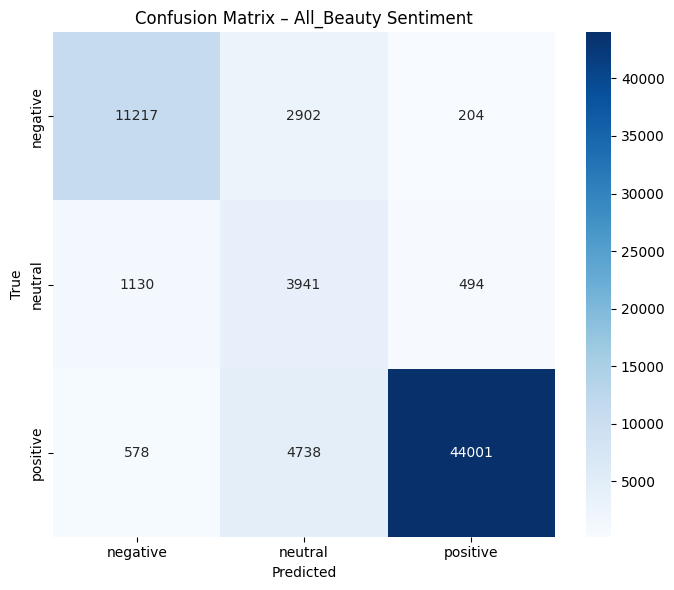

In [15]:
results = trainer.evaluate()
print(results)

preds = trainer.predict(val_dataset)
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=["negative","neutral","positive"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative","neutral","positive"],
            yticklabels=["negative","neutral","positive"])
plt.ylabel("True")
plt.xlabel("Predicted")
plt.title("Confusion Matrix – All_Beauty Sentiment")
plt.tight_layout()
plt.savefig("confusion_matrix_final.png")
plt.show()

## 9. Save all results

In [16]:
final_path = "./beauty_sentiment_model_final"
trainer.save_model(final_path)
tokenizer.save_pretrained(final_path)

# Save mappings
with open(f"{final_path}/label2id.json", "w") as f:
    json.dump(label2id, f)
with open(f"{final_path}/id2label.json", "w") as f:
    json.dump(id2label, f)

torch.save(class_weights.cpu(), f"{final_path}/class_weights.pt")

print(f"\nMODEL SAVED TO → {final_path}")
!zip -r beauty_sentiment_model_final.zip {final_path} confusion_matrix_final.png


MODEL SAVED TO → ./beauty_sentiment_model_final


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  adding: beauty_sentiment_model_final/ (stored 0%)
  adding: beauty_sentiment_model_final/label2id.json (deflated 16%)
  adding: beauty_sentiment_model_final/id2label.json (deflated 20%)
  adding: beauty_sentiment_model_final/model.safetensors (deflated 8%)
  adding: beauty_sentiment_model_final/special_tokens_map.json (deflated 42%)
  adding: beauty_sentiment_model_final/vocab.txt (deflated 53%)
  adding: beauty_sentiment_model_final/tokenizer_config.json (deflated 75%)
  adding: beauty_sentiment_model_final/config.json (deflated 47%)
  adding: beauty_sentiment_model_final/tokenizer.json (deflated 71%)
  adding: beauty_sentiment_model_final/training_args.bin (deflated 52%)
  adding: beauty_sentiment_model_final/class_weights.pt (deflated 58%)
  adding: confusion_matrix_final.png (deflated 14%)
